In [ ]:
import h5py
import sys
sys.path.append("/eos/user/v/vgousyle/")
from WCTE_event_display.EventDisplay import EventDisplay
import matplotlib.colors as colors
import uproot
sys.path.append("/eos/user/v/vgousyle/proton_search/Geometry/")
#sys.path.insert(0, "../../Geometry")
from Geometry.Device import Device
import awkward as ak
sys.path.append("/eos/user/v/vgousyle/proton_search/TimeCal/")
from TimeCal.TC_Multilaterator import TC_Multilaterator
from TimeCal.TC_BeaconData import TC_BeaconData
import numpy as np
import importlib
from matplotlib.backends.backend_pdf import PdfPages
importlib.reload(WCTE_event_display.EventDisplay)
import matplotlib.pyplot as plt
import json


In [66]:
#Read in the data parquet file from the beam PID analysis 
cols = ["trigger_times","trigger_types","window_time",
        "hit_mpmt_card_ids","hit_mpmt_slot_ids","hit_pmt_channel_ids",
        "hit_pmt_position_ids","hit_pmt_times","hit_pmt_calibrated_times",
        "hit_pmt_charges","hit_pmt_readout_mask","window_data_quality","beam_pid",'t0_time']
#Specifying the different column that can be used

# define dictionary to store them all
all_events = {}
run_number=1848
particle_list=['muon']
for particle in particle_list:
    fname = f"/eos/user/v/vgousyle/proton_search/analysis_tools/notebooks/Beam_PID_R{run_number}.parquet"#"/eos/user/v/vgousyle/proton_search/Beam_PID_R1567.parquet"#f"/eos/user/v/vgousyle/proton_search/analysis_tools/notebooks/Beam_PID_R{run_number}.parquet"
    
    try:
        # Read all events first
        df = ak.from_parquet(fname, columns=cols)
        #print(particle)
        # Filter to only keep the particle type you want
        mask = df["beam_pid"] == particle  # Filter for muons only
        df_filtered = df[mask]
        print(f"Found {len(df_filtered)} {particle} events")
        all_events[particle] = df_filtered
        
    except Exception as e:
        print(f"Error reading {particle}: {e}")
all_particle_events = all_events.get(particle_list[0], ak.Array([]))
print(f"Total {particle_list[0]} events: {len(all_particle_events)}")   

Found 752 muon events
Total muon events: 752


In [67]:
#Trigger file path
file_path = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v0_5/{run_number}/run_{run_number}_meta_data_json.json"

#file_path = f"I:/wcte_data/sahar/run_{run_number}_meta_data_json.json"
#file_path = f"/eos/user/v/vgousyle/proton_search/run_1707_meta_data_json.json"
with open(file_path, "r") as f:
    metadata = json.load(f)
print(metadata.keys())

good_pmt_channel_list = metadata["good_wcte_pmts"]
print(len(good_pmt_channel_list),"wcte PMTs stably readout during the run")

print("The run configuration is",metadata["run_configuration"] )
run_configuration_name = metadata["run_configuration"] 
config_file_path = "/eos/experiment/wcte/configuration/tooldaq_run_configs/configurations.json"
#config_file_path = "I:/wcte_data/sahar/configurations.json"
with open(config_file_path, 'r') as f:
    config_data = json.load(f)
run_config = config_data[run_configuration_name]

print(run_config['device_configs'].keys())

#e.g to get the window times
print("Window pre-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_pre_trigger'])
print("Window post-trigger (in CC)",run_config['device_configs']['WCTE_RBU']['WindowBuilder']['main_post_trigger'])

dict_keys(['run_number', 'run_configuration', 'good_wcte_pmts', 'wcte_pmts_with_timing_constant', 'wcte_pmts_slow_control_stable', 'timing_constant_revision_id', 'timing_constant_insert_time'])
1561 wcte PMTs stably readout during the run
The run configuration is Good_mpmt_beam_v46
dict_keys(['MPMT1', 'MPMT3', 'MPMT6', 'MPMT7', 'MPMT8', 'MPMT10', 'MPMT11', 'MPMT12', 'MPMT14', 'MPMT15', 'MPMT16', 'MPMT17', 'MPMT18', 'MPMT19', 'MPMT20', 'MPMT21', 'MPMT22', 'MPMT23', 'MPMT24', 'MPMT25', 'MPMT26', 'MPMT27', 'MPMT28', 'MPMT29', 'MPMT30', 'MPMT31', 'MPMT32', 'MPMT33', 'MPMT34', 'MPMT35', 'MPMT36', 'MPMT38', 'MPMT40', 'MPMT41', 'MPMT42', 'MPMT43', 'MPMT44', 'MPMT45', 'MPMT46', 'MPMT47', 'MPMT48', 'MPMT52', 'MPMT71', 'MPMT73', 'MPMT74', 'MPMT75', 'MPMT76', 'MPMT77', 'MPMT78', 'MPMT79', 'MPMT80', 'MPMT82', 'MPMT83', 'MPMT84', 'MPMT85', 'MPMT86', 'MPMT87', 'MPMT89', 'MPMT91', 'MPMT92', 'MPMT93', 'MPMT94', 'MPMT96', 'MPMT97', 'MPMT98', 'MPMT99', 'MPMT100', 'MPMT101', 'MPMT102', 'MPMT103', 'MPMT10

In [68]:
#Filter the PMTs and channels which are good and bad. 
good_mpmt=np.unique(np.concatenate(all_particle_events['hit_mpmt_slot_ids']))
bad_pmt=0
bad_mpmt=[]
complete_mpmt=np.arange(0,19)
bad_pmt_channels={}
for i in range(1,len(good_mpmt)):
    index=np.where(np.concatenate(all_particle_events['hit_mpmt_slot_ids'])==good_mpmt[i])
    #print(all_particle_events['hit_mpmt_slot_ids'][index])
    test_pmt=np.unique(np.concatenate(all_particle_events['hit_pmt_position_ids'])[index])
    #print(test_pmt)
    mask = ~np.isin(complete_mpmt, test_pmt)
    #print(mask)
    
    if np.any(mask==True):
        print("mpmt",good_mpmt[i],"Channel",complete_mpmt[mask])
        bad_pmt+=len(complete_mpmt[mask])
        bad_pmt_channels.update({good_mpmt[i]:complete_mpmt[mask]})
        #bad_mpmt.append(good_mpmt[i])
    
    
print("Total number of active PMT",(len(good_mpmt)-1)*19-bad_pmt,len(good_pmt_channel_list))

mpmt 4 Channel [15]
mpmt 10 Channel [17]
mpmt 20 Channel [10]
mpmt 22 Channel [17]
mpmt 36 Channel [17]
mpmt 40 Channel [14]
mpmt 57 Channel [16]
mpmt 66 Channel [ 4  5 12 18]
mpmt 84 Channel [6]
Total number of active PMT 1565 1561


(2014,)


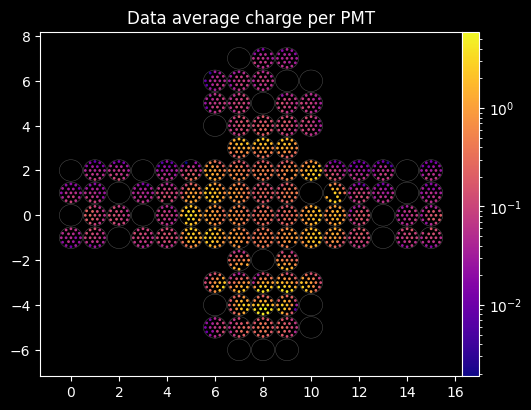

(2014,)


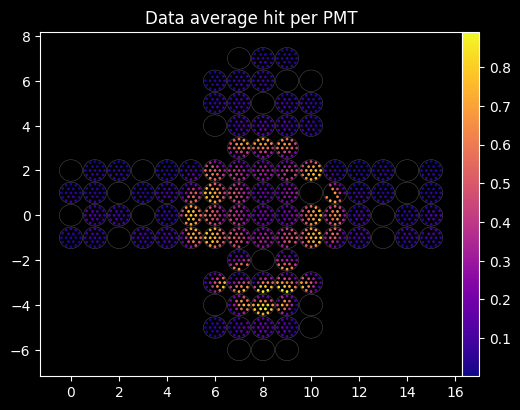

In [69]:
#Plot the the event display for data
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
nEvents = 0 
pmt_slot = []
pmt_pos = []
data_to_plot = []
#Trigger times as to be checked
#1567 1500-1800
#1848 2000-3000
#1610 1500-1800
tr=[2000,3000]
avg_charge_data=np.zeros(2014) #Number of PMTs in WCTE
avg_hit_data=np.zeros(2014)
avg_hit=[] #
avg_total_charge=[] #
for event in all_particle_events:
    if (event['window_data_quality']!=0):
        #print("Event excluded with flag",event['window_data_quality'])
        continue
    #filter out windows which fail the data quality checks 
    pre_hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120) & (event['hit_pmt_calibrated_times']>tr[0]) & (event['hit_pmt_calibrated_times']<tr[1])

    values,edges = np.histogram(event['hit_pmt_calibrated_times'][pre_hit_mask],bins=np.arange(tr[0],tr[1],1))
    peak_time = edges[np.argmax(values)]
    min_time = peak_time - 20
    max_time = peak_time + 20
    #print(min_time,max_time)
    #apply a mask to hits, don't include hits labelled as bad or hits on trigger mainboards in the event display
    hit_mask = (event['hit_pmt_readout_mask']==0) & (event['hit_mpmt_card_ids']<120) & (event['hit_pmt_calibrated_times']>min_time) & (event['hit_pmt_calibrated_times']<max_time)
    nEvents+=1
    #pmt_slot.extend(event['hit_mpmt_slot_ids'][hit_mask])
    pmt_slot=event['hit_mpmt_slot_ids'][hit_mask]
    pmt_pos=event['hit_pmt_position_ids'][hit_mask]
    data_to_plot=event['hit_pmt_charges'][hit_mask]
                                        
    #pmt_pos.extend(event['hit_pmt_position_ids'][hit_mask])
    #data_to_plot.extend(event['hit_pmt_charges'][hit_mask])
    ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,data_to_plot,sum_data=True)
    avg_charge_data+=ev_disp_data
    #eventDisplay.plotEventDisplay(ev_disp_data/135,color_norm=colors.LogNorm(), style= "dark_background")
    #plt.show(block=False)
    hit_array = (data_to_plot> 0)
    ev_disp_data = eventDisplay.process_data(pmt_slot,pmt_pos,hit_array,sum_data=True)
    avg_hit_data+=ev_disp_data
    avg_hit.append(len(data_to_plot))
    avg_total_charge.append(np.sum(data_to_plot/135))
    
#average by each event
#ev_disp_data = ev_disp_data/nEvents
total_charge_data= (avg_charge_data/(nEvents*135))
total_hit_data= (avg_hit_data/(nEvents))
eventDisplay.plotEventDisplay(total_charge_data,color_norm=colors.LogNorm(), style= "dark_background")
plt.title("Data average charge per PMT")
plt.show(block=False)
plt.style.use('default')
eventDisplay.plotEventDisplay(total_hit_data,color_norm=colors.Normalize(),  style= "dark_background")
plt.title("Data average hit per PMT")
plt.show(block=False)
#plt.style.use('default')

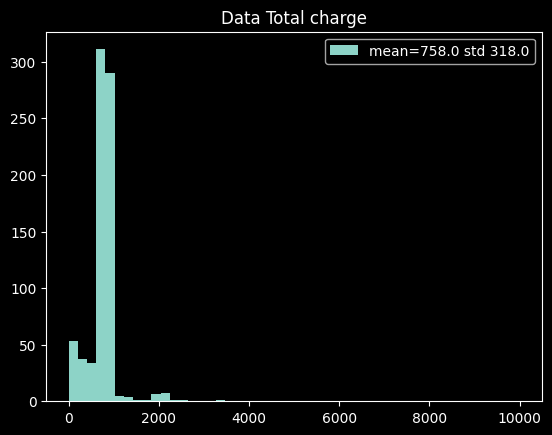

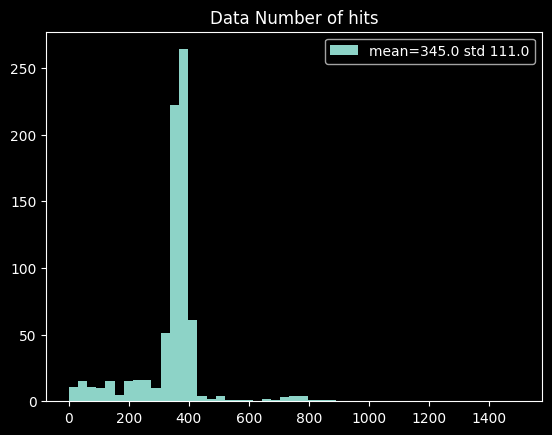

In [70]:
#1D distribution
plt.hist(avg_total_charge,bins=np.linspace(0,10000),label="mean="+str(np.round(np.mean(avg_total_charge)))+" std "+str(np.round(np.std(avg_total_charge))))
plt.title("Data Total charge")
plt.legend()
plt.show()
plt.hist(avg_hit,bins=np.linspace(0,1500),label="mean="+str(np.round(np.mean(avg_hit)))+" std "+str(np.round(np.std(avg_hit))))
plt.title("Data Number of hits")
plt.legend()

In [71]:
#For MC file is root and created with tuple_convert_to_root
file_path="/eos/user/v/vgousyle/wc_sim_build/out_muon_320_pq.root"
with uproot.open(file_path) as root_file:
    tree = root_file["WCTEReadoutWindows"]
    branches_to_load = ["window_time"]
    all_events_mc = tree.arrays(entry_start=0,entry_stop=200,library="ak")    



In [75]:
#Prepare a channel mask for the MC to match the data
filtered_charge=[]
channel_mask=np.zeros(len(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])))
for mpmt in np.unique(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])):
    if mpmt not in good_mpmt:
        continue 
    #hit_mpmt_slot_ids
    #print(mpmt)
    try:
        #print(bad_pmt_channels[mpmt])
        index=np.where(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])==mpmt) #All the channels
        #index_2=np.where(np.concatenate(event_mc['hit_pmt_position_ids'])[index]
        
        test_pmt=np.concatenate(all_events_mc['hit_pmt_position_ids'])[index] 
        mask = ~np.isin(bad_pmt_channels[mpmt], test_pmt)
        channel_mask[index][mask]=True
        #for i in range(0,len(bad_pmt_channels[mpmt])):
        #    channel_mask[index]=True
    except:
        index=np.where(np.concatenate(all_events_mc['hit_mpmt_slot_ids'])==mpmt)
        channel_mask[index]=True
lengths = [len(x) for x in all_events_mc['hit_mpmt_slot_ids']]
rebuilt_mask=np.split(channel_mask, np.cumsum(lengths)[:-1])
rebuilt_mask = [x.tolist() for x in rebuilt_mask]

(2014,)


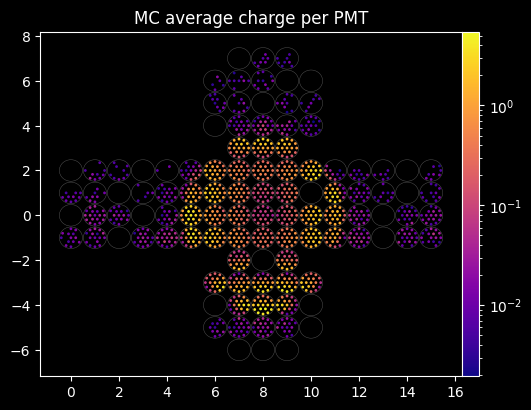

(2014,)


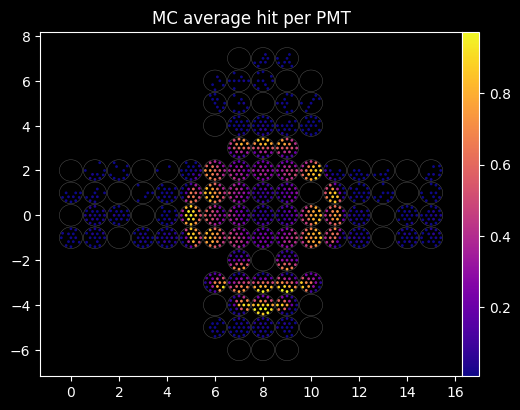

In [76]:
eventDisplay = EventDisplay() 
#load the positions of the mPMTs (an internal file to the event display class that 
#specificies where to plot and what orientation to plot mPMTs on the event display)
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')
#e.g. select a single event randomly
total_charge_mc=np.zeros(2014)
nevents=0
avg_hit_mc=[]
avg_charge_mc=[]
total_hit_mc=np.zeros(2014)
for i in range(1,180):
        nevents+=1
    #print(all_events_beam["is_muon"][i])
        event_mc=all_events_mc[i]
        values,edges = np.histogram(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)],bins=np.arange(0,50,1))
        peak_time = edges[np.argmax(values)]
        #print(peak_time)
        min_time = peak_time - 8
        max_time = peak_time + 4
        #print(min_time,max_time)
        pre_hit_mask =(event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]>min_time) & (event_mc['hit_pmt_times'][np.array(rebuilt_mask[i],dtype=bool)]<max_time)
        #plt.hist(event_mc['hit_pmt_times'],bins=np.linspace(5,50,100))
        #plt.show()
        #pre_hit_mask =  (event_mc['hit_pmt_times']<20)
        pmt_slot = event_mc['hit_mpmt_slot_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        pmt_pos = event_mc['hit_pmt_position_ids'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]
        mc_to_plot  = event_mc['hit_pmt_charges'][np.array(rebuilt_mask[i],dtype=bool)][pre_hit_mask]

        #this function processes pmt positions and the data to plot into an array for use by the event display
        #sum_data will sum data for the same channel e.g. if a channel has 2 hits in event['hit_pmt_charges'] they will be summed
        #if summed data is false it will by default take the smallest value for each channel for plotting time distributions
        hit_array = (mc_to_plot> 0)
        ev_disp_mc = eventDisplay.process_data(pmt_slot,pmt_pos,hit_array,sum_data=True)
        total_hit_mc+=ev_disp_mc
        avg_hit_mc.append(np.sum(hit_array))
        ev_disp_mc = eventDisplay.process_data(pmt_slot,pmt_pos,mc_to_plot,sum_data=True)
        total_charge_mc+=ev_disp_mc
        avg_charge_mc.append(np.sum(mc_to_plot))
        #print(ev_disp_mc)
        #this pltos the event display, colors.Normalize() will plot on a linear scale
        #eventDisplay.plotEventDisplay(ev_disp_mc,color_norm=colors.LogNorm(), style= "dark_background")

        #optional ability to draw the mPMT slot id for each mPMT
        # eventDisplay.label_mPMTs(np.arange(0,106))
        #fig = plt.gcf()  
        #plt.show()
        #pdf_global.savefig(fig)
        #plt.close() 

        #plt.show(block=False)
        #plt.style.use('default') 
        #plt.hist(all_events[i]['hit_pmt_calibrated_times'][hit_mask],bins=np.linspace(428,440,100))
        #plt.yscale("log")   
        #plt.show()
total_charge_mc=total_charge_mc/nevents
total_hit_mc=total_hit_mc/nevents
eventDisplay.plotEventDisplay(total_charge_mc,color_norm=colors.LogNorm(), style= "dark_background")

plt.title("MC average charge per PMT")
plt.show()
plt.style.use('default')
eventDisplay.plotEventDisplay(total_hit_mc,color_norm=colors.Normalize(),  style= "dark_background")
plt.title("MC average hit per PMT")
plt.show(block=False)
#plt.style.use('default')

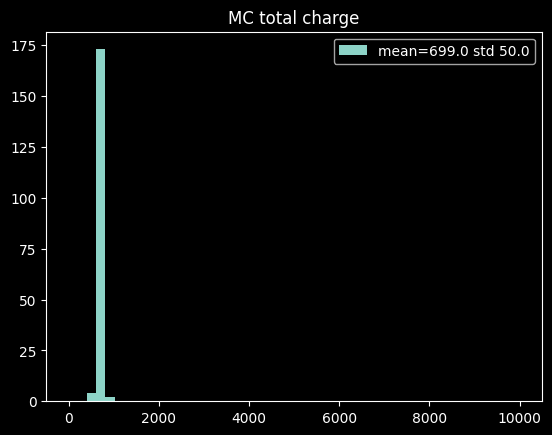

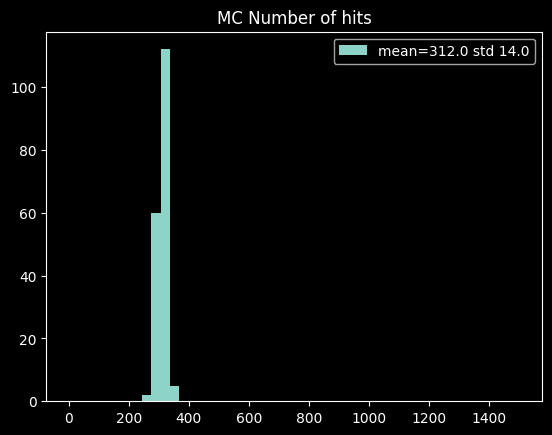

In [74]:
#1D distribution
plt.title("MC total charge")
plt.hist(avg_charge_mc,bins=np.linspace(0,10000),label="mean="+str(np.round(np.mean(avg_charge_mc)))+" std "+str(np.round(np.std(avg_charge_mc))))
plt.legend()
plt.show()
plt.title("MC Number of hits")
plt.hist(avg_hit_mc,bins=np.linspace(0,1500),label="mean="+str(np.round(np.mean(avg_hit_mc)))+" std "+str(np.round(np.std(avg_hit_mc))))
plt.legend()
plt.show()

(2014,)


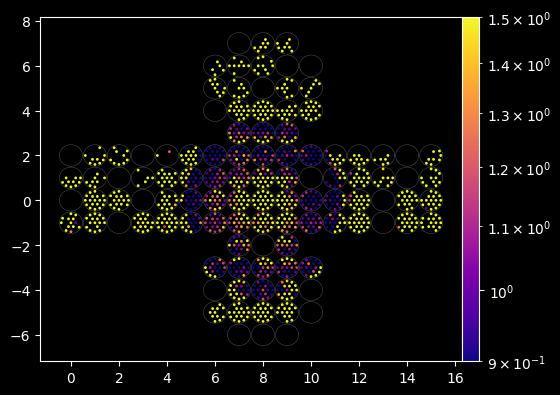

In [77]:
#ratio data/MC for the charge
ratio_mc=total_charge_data/(total_charge_mc)
eventDisplay.plotEventDisplay(ratio_mc,color_norm=colors.LogNorm(vmin=0.9, vmax=1.5), style= "dark_background")
#plt.c_lim(1,10)
plt.show(block=False)
plt.style.use('default')


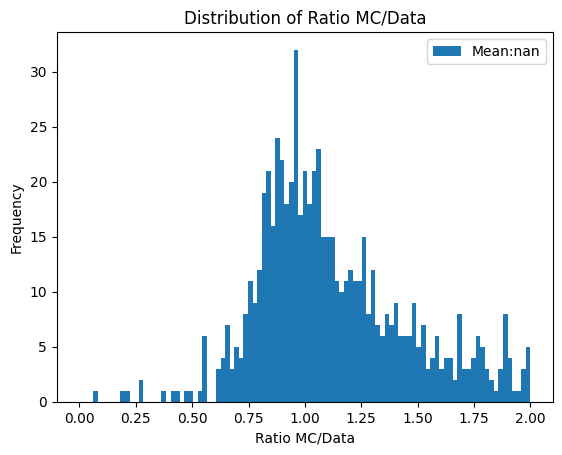

In [78]:
plt.hist(ratio_mc,bins=np.linspace(0,2,100),label="Mean:{:.3f}".format(np.mean(ratio_mc)))
plt.xlabel("Ratio MC/Data")
plt.ylabel("Frequency")
plt.title("Distribution of Ratio MC/Data")
plt.legend()
plt.show()

In [64]:
#mask_zero=ratio_mc[np.isfinite(ratio_mc)]
np.mean(ratio_mc[np.isfinite(ratio_mc)])

np.float64(11.19156377062909)

Ratio total charge: 0.82
Ratio nb hits: 0.78


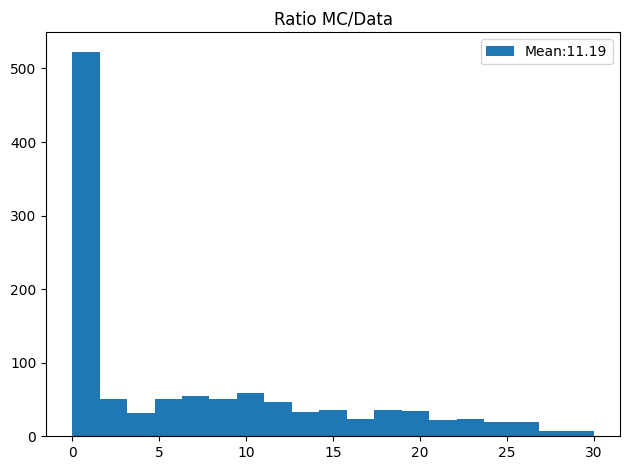

In [65]:
#1D visiulazation of the ratio
figure,ax=plt.subplots()
mask_zero=ratio_mc[np.isfinite(ratio_mc)]>1
ax.hist(ratio_mc[np.isfinite(ratio_mc)][mask_zero],bins=np.linspace(0,30,20),label="Mean:{:.2f}".format(np.mean(ratio_mc[np.isfinite(ratio_mc)])))
ax.set_title("Ratio MC/Data")
ax.legend()
plt.tight_layout()
print("Ratio total charge: {:.2f}".format(np.mean(avg_charge_mc)/np.mean(avg_total_charge)))
print("Ratio nb hits: {:.2f}".format(np.mean(avg_hit_mc)/np.mean(avg_hit)))